<a href="https://colab.research.google.com/github/hdpark1208/StudyCode/blob/main/Algorithm/PG/%EC%84%A0%EC%9D%B8%EC%9E%A5_%EC%88%A8%EA%B8%B0%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선인장_숨기기


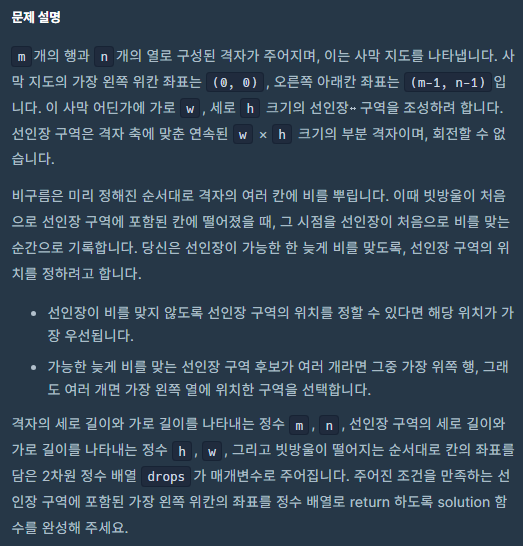

## 입력 출력 및 예제


* 입력

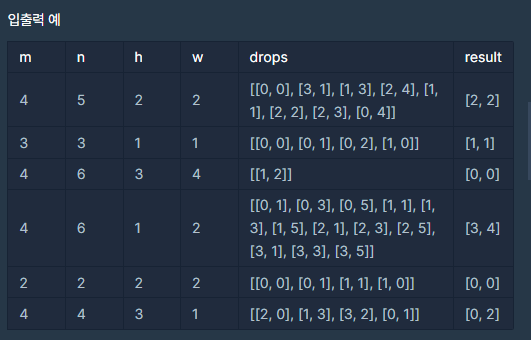

* 출력

* 예제

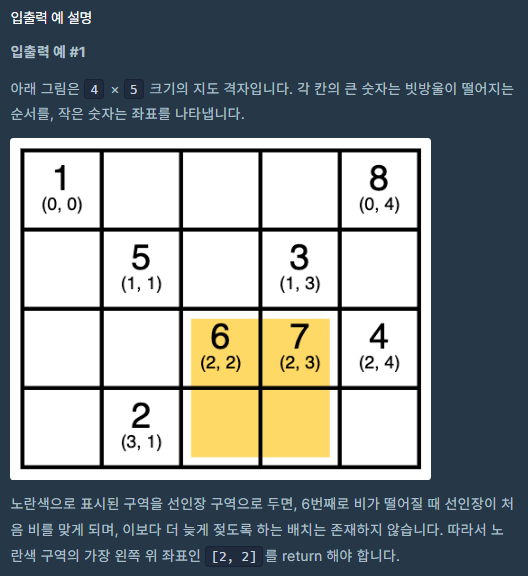

## 구상

* 선인장이 위치할수 있는 모든 구역에서, 순서대로 비가 떨어지면 선인장이 닿는 구역을 소거해나가기
* 너무 비효율적인가 ?
* 반대로, 비가 내릴 예정인 지역을 다 막아두고, 가장 나중에 내릴 지역부터 제한을 풀면서 선인장이 위치할 수 있는지 판단하는건?
* 한 구역이 풀릴 때마다 봐야할 곳은 최대 선인장 크기 만큼이다.

## 코드

In [ ]:
# O(nm) 풀이 # 선인장이 위치할 수 있는 구역의 최솟값들 중 최댓값

from collections import deque

def solution(m, n, h, w, drops):
    INF = len(drops) + 1

    # 1) 각 칸이 처음 젖는 시점
    rain = [[INF] * n for _ in range(m)]
    for t, (r, c) in enumerate(drops, start=1):
        rain[r][c] = t

    # 2) 각 행에 대해 길이 w 구간의 최소값
    # row_min[i][j] = rain[i][j:j+w] 의 최소값
    width_cnt = n - w + 1
    row_min = [[0] * width_cnt for _ in range(m)]

    for i in range(m):
        dq = deque()
        for j in range(n):
            while dq and rain[i][dq[-1]] >= rain[i][j]:
                dq.pop()
            dq.append(j)

            if dq[0] <= j - w:
                dq.popleft()

            if j >= w - 1:
                row_min[i][j - w + 1] = rain[i][dq[0]]

    # 3) 각 열에 대해 높이 h 구간의 최소값
    # row_min의 각 열마다 슬라이딩 최소값
    height_cnt = m - h + 1

    best_val = -1
    best_r = 0
    best_c = 0

    for c in range(width_cnt):
        dq = deque()
        for r in range(m):
            while dq and row_min[dq[-1]][c] >= row_min[r][c]:
                dq.pop()
            dq.append(r)

            if dq[0] <= r - h:
                dq.popleft()

            if r >= h - 1:
                val = row_min[dq[0]][c]   # h x w 구간의 최소값
                top_r = r - h + 1

                if val > best_val:
                    best_val = val
                    best_r = top_r
                    best_c = c
                elif val == best_val:
                    if top_r < best_r or (top_r == best_r and c < best_c):
                        best_r = top_r
                        best_c = c

    return [best_r, best_c]

In [ ]:
# 2차원 누적합 + 이분 탐색 # 시간 초과

def solution(m, n, h, w, drops):
    # 1) 각 칸이 몇 번째 비에 젖는지 기록
    INF = len(drops) + 1
    rain = [[INF] * n for _ in range(m)]

    for t, (r, c) in enumerate(drops, start=1):
        rain[r][c] = t

    # 2) 주어진 시점 t까지 안 젖는 h x w 직사각형이 있는지 판정
    #    있으면 그 중 가장 위, 가장 왼쪽 좌표도 함께 반환
    def check(t):
        # blocked[r][c] = 1 if rain[r][c] < t else 0
        ps = [[0] * (n + 1) for _ in range(m + 1)]

        for i in range(1, m + 1):
            row_sum = 0
            for j in range(1, n + 1):
                blocked = 1 if rain[i - 1][j - 1] < t else 0
                row_sum += blocked
                ps[i][j] = ps[i - 1][j] + row_sum

        for r in range(m - h + 1):
            r2 = r + h
            for c in range(n - w + 1):
                c2 = c + w
                cnt = ps[r2][c2] - ps[r][c2] - ps[r2][c] + ps[r][c]
                if cnt == 0:
                    return True, [r, c]
        return False, None

    # 3) 가능한 최대 t를 이분탐색
    #    t = len(drops)+1 이 가능하면 끝까지 안 젖는다는 뜻
    left, right = 1, len(drops) + 1
    best_t = 1
    best_pos = [0, 0]

    while left <= right:
        mid = (left + right) // 2
        ok, pos = check(mid)

        if ok:
            best_t = mid
            best_pos = pos
            left = mid + 1
        else:
            right = mid - 1

    return best_pos

In [ ]:
solution(0, cities)

25

### 메모



*